In [82]:
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as colors
import cmasher as cmr
###import libraries

In [2]:
import sys
sys.path.append('/home/vadilloj/MAP2023/Vadillo-Justice-League-Code')
from Runnable_Modules import Base as base, IonUtils as ions, TrackingUtils as tracking
simulations  = base.get_chars("sims")##import modules previously run

In [3]:
##temporary reload! this is helpful if you are modifying the underlying custom modules while also working on this code and
##want to avoid fully restarting the kernel when you hit a roadblock
import importlib
importlib.reload(base)
importlib.reload(tracking)

<module 'Runnable_Modules.TrackingUtils' from '/home/vadilloj/MAP2023/Vadillo-Justice-League-Code/Runnable_Modules/TrackingUtils.py'>

In [4]:
def get_rbins():
    nbins = 100
    start = 0.1
    end = edge
    edges, binwidth = np.linspace(start, end, num = (nbins+1), endpoint = True, retstep = True)#edges of bins and their widths
    r_bins = edges[0:-1] + (binwidth/2)#midpoints of bins and their widths
    return edges,r_bins

In [5]:
def getHaloChars(h1, subsims,edge):
    """
    function designed to get the halo charachteristics (ie the mass fractions and total mass) for the galaxies,and save it to a datafile
    only should need to be run once! 

    parameters
    h1: (subsim) the central halo ie, the h1 of the simulation you are looking at
    subsims: (dict of subsims)  a dictionary containing all of the subsims of the tracked particles in that halo, should be returned by "tracking.findhaloparticles()"
    edge: (int) an integer representing the edge of the central halo, often just np.max(h1['r'])

    returns 
    HaloChars:  a PD dataframe, where each cell contains an array of the profile of a specific property varying across radius. 
            Indexes denote the specific subhalos that these properties vary for while columns denote the properties themselves.
    """
    ########## parameters for halo charachteristics

    edges,r_bins = get_rbins()
    nbins = len(r_bins)
    mass_keys = ['mass','HI_mass', 'OVI_mass']
    mass_name = ['Mass','HI', 'OVI']
    ################## constant plot Charachteristics defined from the above
    bin_areas = 4/3*np.pi*(edges[1:]**3 - edges[0:-1]**3) ##calculate the area in each bin,by finding the difference in the volume of spheres enclosing its edges. 
    ########

    Chars = {}

    for i in range(len(mass_keys)):
        mass_key = mass_keys[i]
        name = mass_name[i]
        Ratios, Densities = {}, {}
        total_hist, bin_edges = np.histogram(h1.g['r'], bins = edges, weights = h1.g[mass_key])#make histogram for total mass
        
        for halo in subsims:
            #for each satelite, calculate the ratio of total mass, in a given virial bin and its density
            subsnap = subsims[halo]
            halo_hist, bin_edges = np.histogram(subsnap['r'], bins = edges, weights = subsnap[mass_key])
            Ratios[halo] = halo_hist/total_hist
            Densities[halo] = halo_hist/bin_areas
            
        Densities['total'] = total_hist/bin_areas
        Ratios['total'] = np.ones(nbins)
        Chars[name + "_Density"] = Densities
        Chars[name + "_Ratios"] = Ratios
        
    
    indexes = list(Chars['Mass_Ratios'].keys())
    indexes.insert(0, indexes.pop(indexes.index('local')))    

    HaloChars = pd.DataFrame(Chars, index = indexes)##data frame to store halo data
    return HaloChars 

In [25]:
def makeStackplot(sHaloChars, value , ax,rbins, cmapN, local_color = 'black',grouped_color = 'white'):
    values, labels, grouped = group_smalls(sHaloChars, value, len(rbins))
    nHalos  = len(labels)
    
    cmap = mpl.colormaps[cmapN]
    segmentedCmap =cmap(np.linspace(0.35,1, nHalos))
    segmentedCmap[0] = colors.to_rgba(local_color)
    segmentedCmap[-1] = colors.to_rgba(grouped_color)
        
    ax.stackplot(rbins, values, labels = labels, colors = segmentedCmap)

In [14]:
def group_smalls(sHaloChars, value,nbins):
    ion = value.split("_")[0]
    grouped = False
    small_values = np.zeros(nbins)
    values, labels, fractions = [], [], []
    halos_grouped = 0
    
    for subsim_label in list(sHaloChars.index):
        subsim_frac = sHaloChars[ion +"_Ratios"][subsim_label]
        profile_values = sHaloChars[value][subsim_label]
        if np.max(subsim_frac)<0.05:
            small_values += profile_values
            grouped = True
            halos_grouped+=1
        else:
            values.append(profile_values)
            labels.append(subsim_label)
            fractions.append(subsim_frac)
    
    small_label = f"<0.5 ({halos_grouped})"
    while(len(labels) > 6):
        index = np.argmin(np.sum(fractions, axis = 1))
        small_values += values.pop(index) 
        labels.pop(index)
        fractions.pop(index)
        halos_grouped+=1
        small_label = f"smallest {halos_grouped}"
    
    if grouped:
        values.append(small_values)
        labels.append(small_label)
    return values, labels, grouped
                

In [27]:
def make_all_stacks(sHaloChars, filename,edge, group_smalls = False):
    plots_filepath  =  '/home/vadilloj/MAP2023/Vadillo-Justice-League-Code/MassFracs-Divided-By-Source-c/Plots/'
    edges,r_bins = get_rbins()
    ######################
    values = ["Density", "Ratios"]

    ions = ["Mass", "HI", "OVI"]
    cmaps = ['cmr.neutral', 'cmr.amethyst', 'cmr.ember']
    localC = ['black','Indigo', 'maroon']
    GroupedColors= ['burlywood', 'skyblue', 'lightcoral']
    yranges = [(10**1, 10**7), (10**-3.5, 10**3.5), (10**-3, 10**-1)]
   ##############
    fig, axs = plt.subplots(len(ions),len(values), figsize = (11,13))
    for row in (range(len(ions))):
        for col in (range(len(values))):
            ax = axs[row, col]
            Hcolumn = ions[row] + '_' + values[col]
            makeStackplot(sHaloChars, Hcolumn, ax, r_bins,
                          cmapN = cmaps[row],local_color = localC[row],grouped_color =GroupedColors[row])
            
            ax.set_xlim(1,edge)
    
            if (col == 0):
                ax.set_yscale("log")
                ax.set_title(ions[row] + " Log Density(Msol/kpc**3) Profile  divided by source")
                ax.set_ylabel('Log '+ ions[row]+ ' mass')
                ax.legend(loc = 'lower left')
                median = np.median(sHaloChars[Hcolumn]['local'])
                ax.set_ylim(yranges[row])
                

                    
                    
            else:
                ax.axhline(1,color = 'black', linestyle = '--')
                ax.set_title("fraction of total " +ions[row] +" divided by source")
                ax.set_ylabel('fraction of '+ ions[row]+ ' mass')
                ax.legend(loc = 'lower left')
                
    
    
    fig.supxlabel('radius (kpc)')
    name = filename + ' (all)Mass Divided by Source'
    fig.suptitle(name, fontsize = 18)
    fig.tight_layout()
    fig.subplots_adjust(top=0.93)
    fig.savefig(plots_filepath+ name + '.png')


subsims = tracking.find_halo_particles(h1, simulations, filename, groupSmalls = group, h = h)

In [9]:
directory_path = '/home/vadilloj/MAP2023/Vadillo-Justice-League-Code/'
Hchars_path = '/home/vadilloj/MAP2023/Vadillo-Justice-League-Code/All_halo_charachteristics.csv'
HChars = pd.read_csv(Hchars_path, index_col = 0)

In [10]:
def readInData(filename):
    import ast
    def string_to_list(x):
        if isinstance(x, str):
            # Try to detect list-like pattern: [ ... ]
            if x.strip().startswith("[") and x.strip().endswith("]"):
                # Replace spaces with commas inside brackets
                inside = x.strip()[1:-1]
                fixed = "[" + ",".join(inside.split()) + "]"
                try:
                    return ast.literal_eval(fixed)
                except (SyntaxError, ValueError):
                    return x
        return x

        
    data_name = data_filepath + filename +"Halo Charachteristics.csv"
    
    HaloChars  = pd.read_csv(data_name, index_col = 0)
    HaloChars  = HaloChars.map(string_to_list)
    return(HaloChars)

    

In [19]:
HaloChars

,Unnamed: 0,Mass_Density,Mass_Ratios,HI_Density,HI_Ratios,OVI_Density,OVI_Ratios
0,local,"[8888891.07, 2646403.29, 1540052.48, 1086112.3...","[0.99412371, 0.99463431, 0.99474046, 0.9940070...","[2880910.58, 1043595.56, 660039.014, 504927.49...","[0.99421443, 0.99425122, 0.99443914, 0.9939922...","[1667.8196, 367.707013, 135.338163, 48.0049606...","[0.99006591, 0.99494728, 0.9938809, 0.99118774..."
1,h14,"[1987.82357, 314.747425, 86.2012072, 145.24833...","[0.000222315982, 0.000118295873, 5.5678511e-05...","[787.463735, 180.830949, 41.2951708, 60.111492...","[0.000271757068, 0.000172280719, 6.22168288e-0...","[0.0359329377, 0.0, 2.01583085e-06, 0.00128130...","[2.13308302e-05, 0.0, 1.48036278e-08, 2.645582..."
2,h18,"[44211.7214, 12367.9595, 7486.71096, 5897.7034...","[0.00494459, 0.00464842, 0.00483577, 0.0053975...","[13653.6487, 5207.80055, 3381.55616, 2727.2644...","[0.00471193195, 0.00496156009, 0.00509477735, ...","[13.2692867, 1.80925061, 0.830827243, 0.408950...","[0.00787703, 0.0048955, 0.00610133, 0.00844385..."
3,h20,"[379.693452, 100.342841, 29.5827606, 99.882998...","[4.24644942e-05, 3.77132362e-05, 1.91079002e-0...","[145.69298, 0.00503579422, 5.10037812e-06, 44....","[5.02792641e-05, 4.79768673e-09, 7.68441797e-1...","[0.0, 0.0, 0.00209414949, 8.14920722e-06, 0.0,...","[0.0, 0.0, 1.53787753e-05, 1.68261658e-07, 0.0..."
4,h22,"[2384.84466, 556.061487, 114.796232, 173.58508...","[0.00026671838, 0.000208992271, 7.41484196e-05...","[831.252946, 254.390851, 71.8648335, 91.368794...","[0.00028686891, 0.000242362487, 0.000108274211...","[3.23984298, 0.000444984476, 0.0, 0.0154377291...","[0.00192326442, 1.20404583e-06, 0.0, 0.0003187..."
5,h49,"[3578.36739, 937.27795, 425.49669, 231.799695,...","[0.000400200637, 0.00035227012, 0.000274833995...","[1346.63242, 391.061968, 196.189785, 128.39725...","[0.000464728548, 0.000372571383, 0.00029558677...","[0.189449245, 0.0576591217, 0.000322621344, 0....","[0.000112462547, 0.000156014937, 2.36922969e-0..."
6,halos,"[52542.4505, 14276.3892, 8142.78785, 6548.2195...","[0.00587629, 0.00536569, 0.00525954, 0.0059929...","[16764.6908, 6034.08936, 3690.90595, 3051.8361...","[0.00578556574, 0.00574877948, 0.00556085517, ...","[16.7345119, 1.86735471, 0.83324603, 0.4267934...","[0.00993409, 0.00505272, 0.0061191, 0.00881226..."
7,total,"[8941433.52, 2660679.68, 1548195.27, 1092660.5...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[2897675.27, 1049629.64, 663729.92, 507979.335...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1684.55411, 369.574368, 136.171409, 48.431754...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."


In [9]:
data_filepath  = '/home/vadilloj/MAP2023/Vadillo-Justice-League-Code/MassFracs-Divided-By-Source-c/Data/'
filenames  = [  'Ruth','Sonia',  'Elena', 'Sandra']

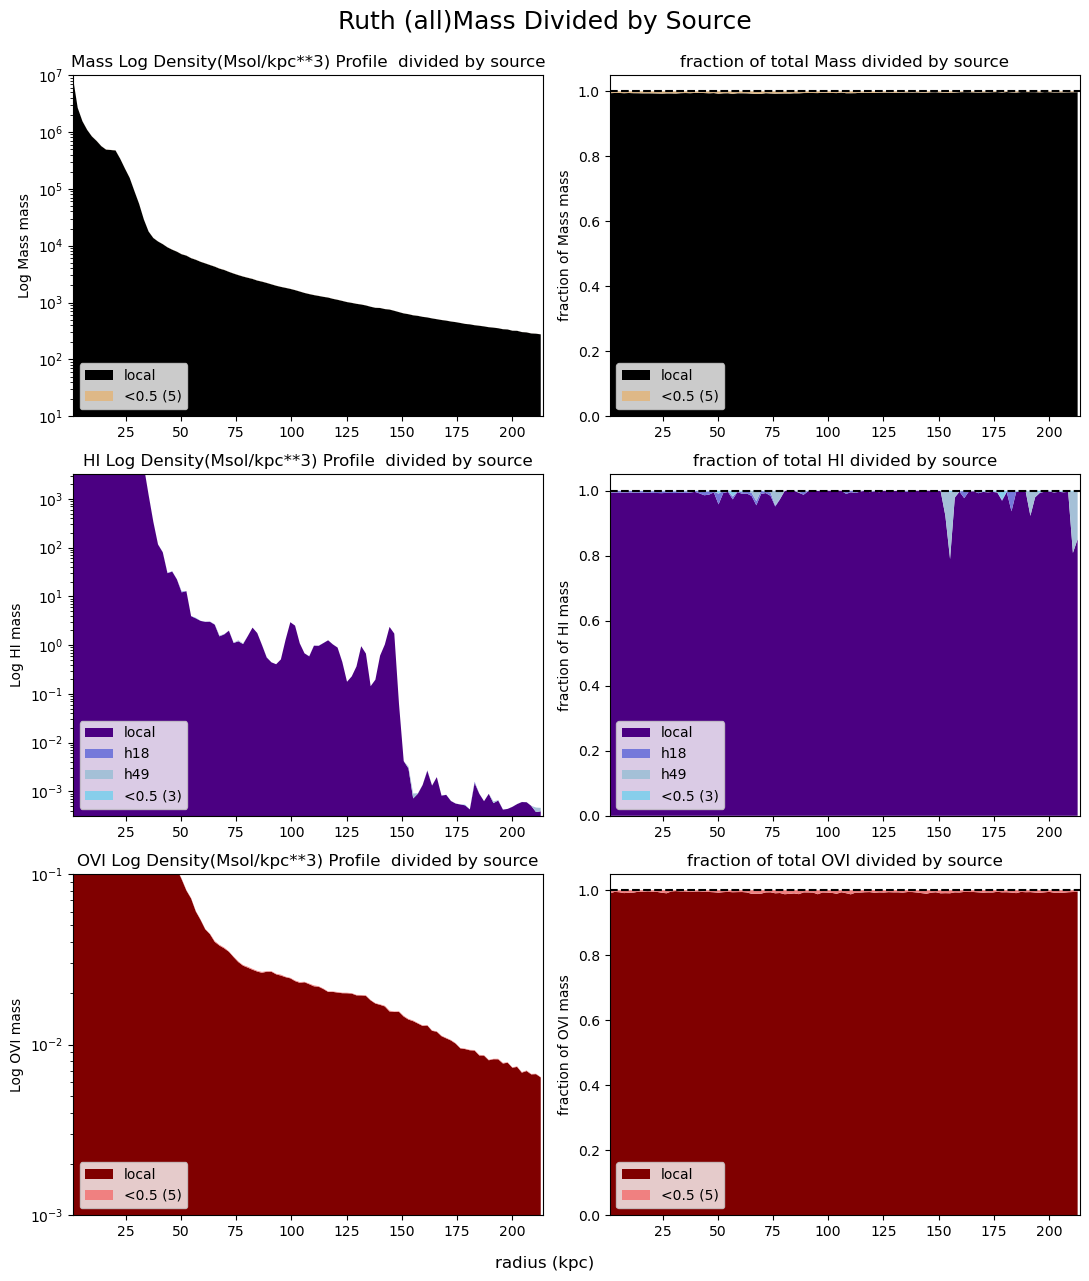

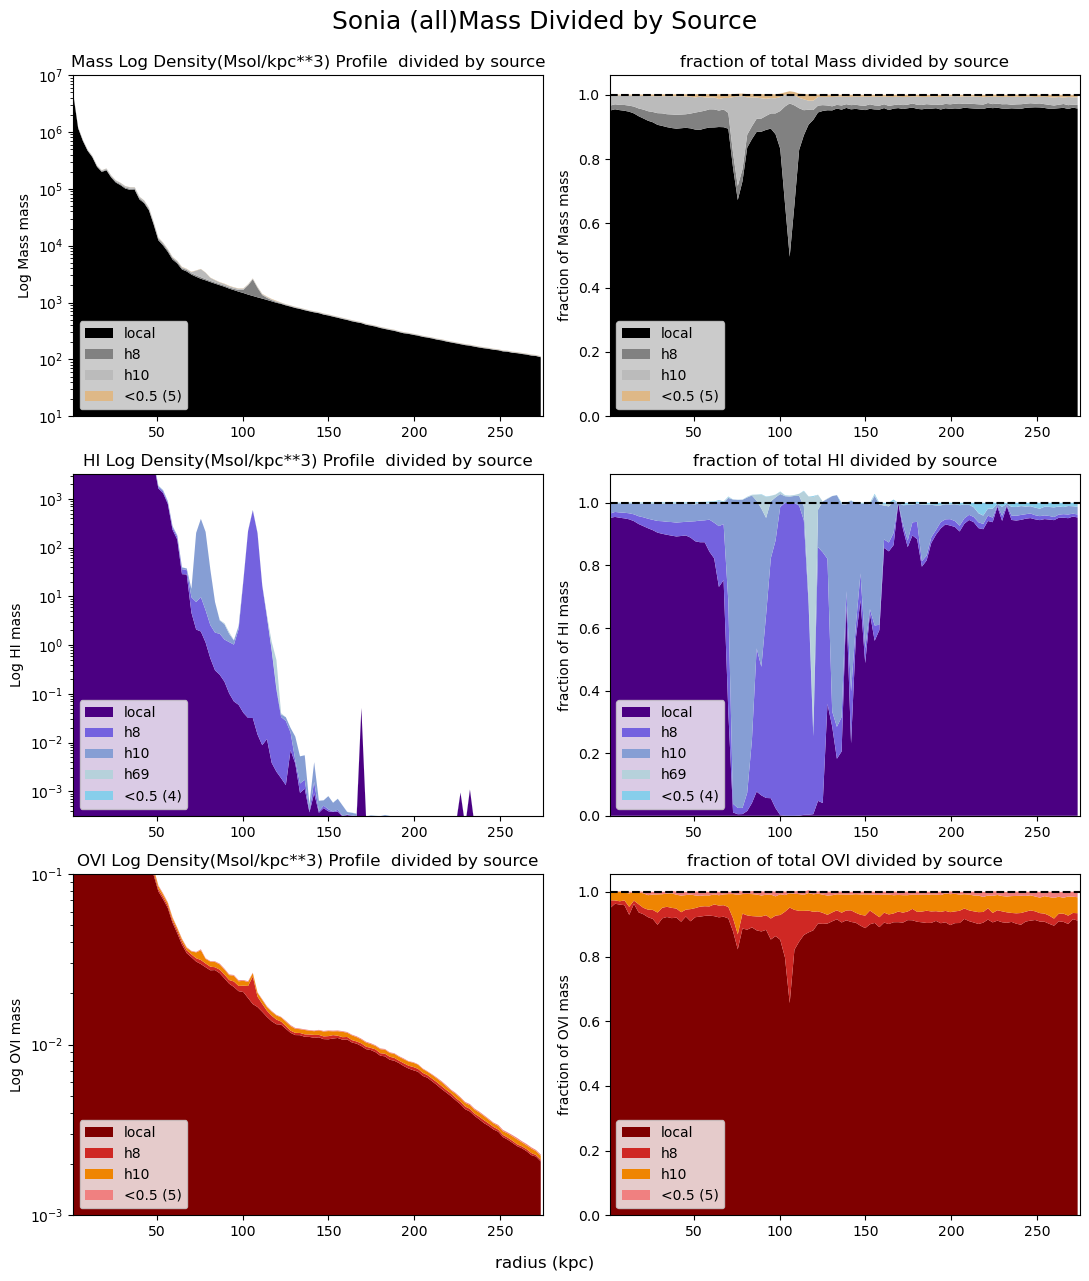

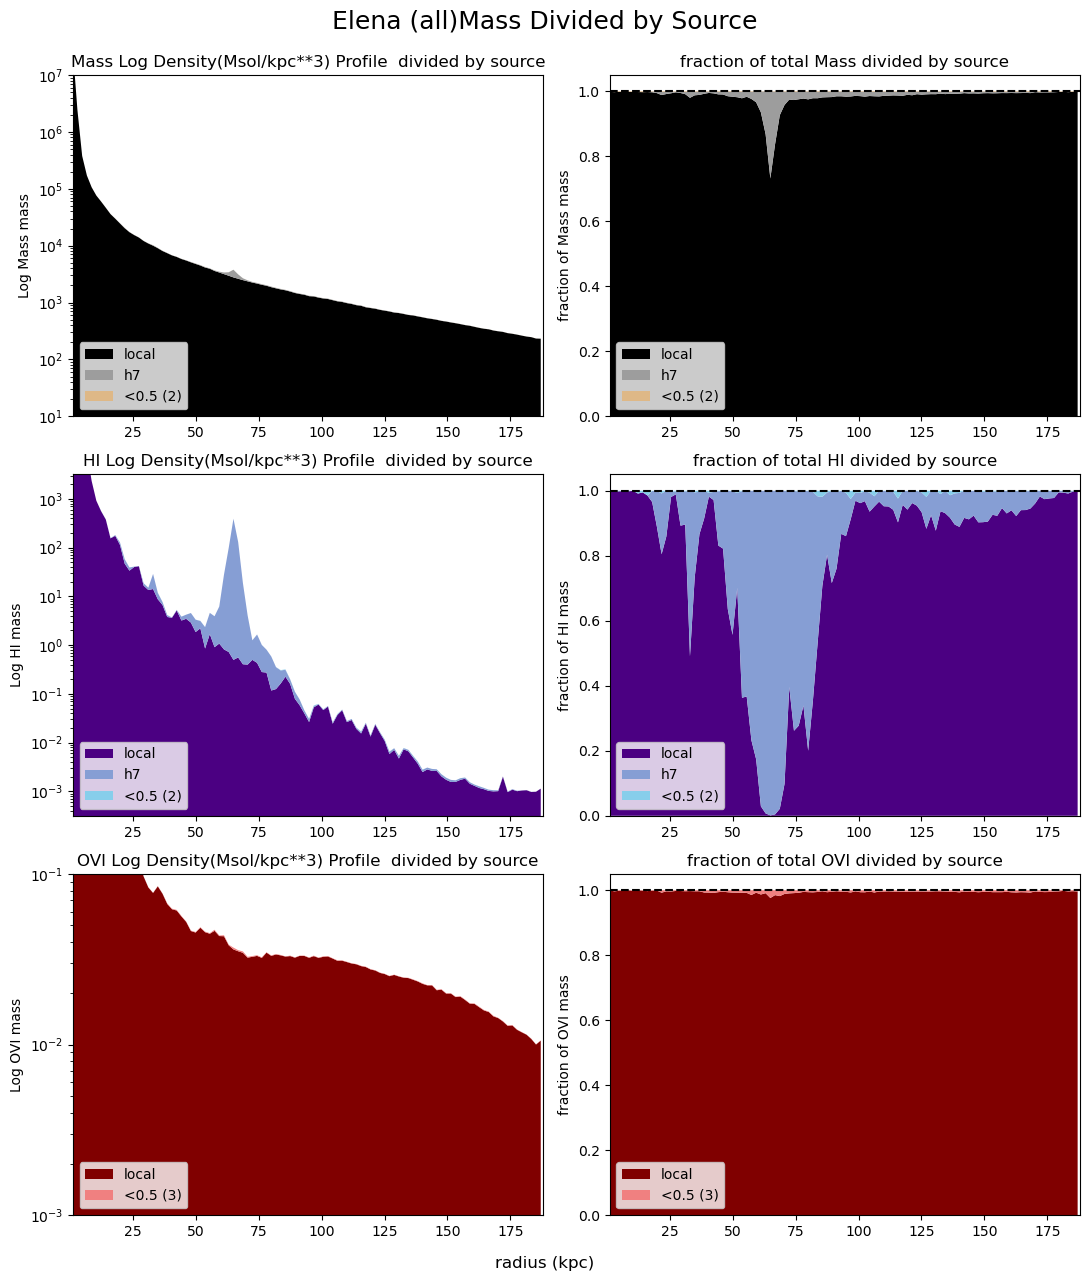

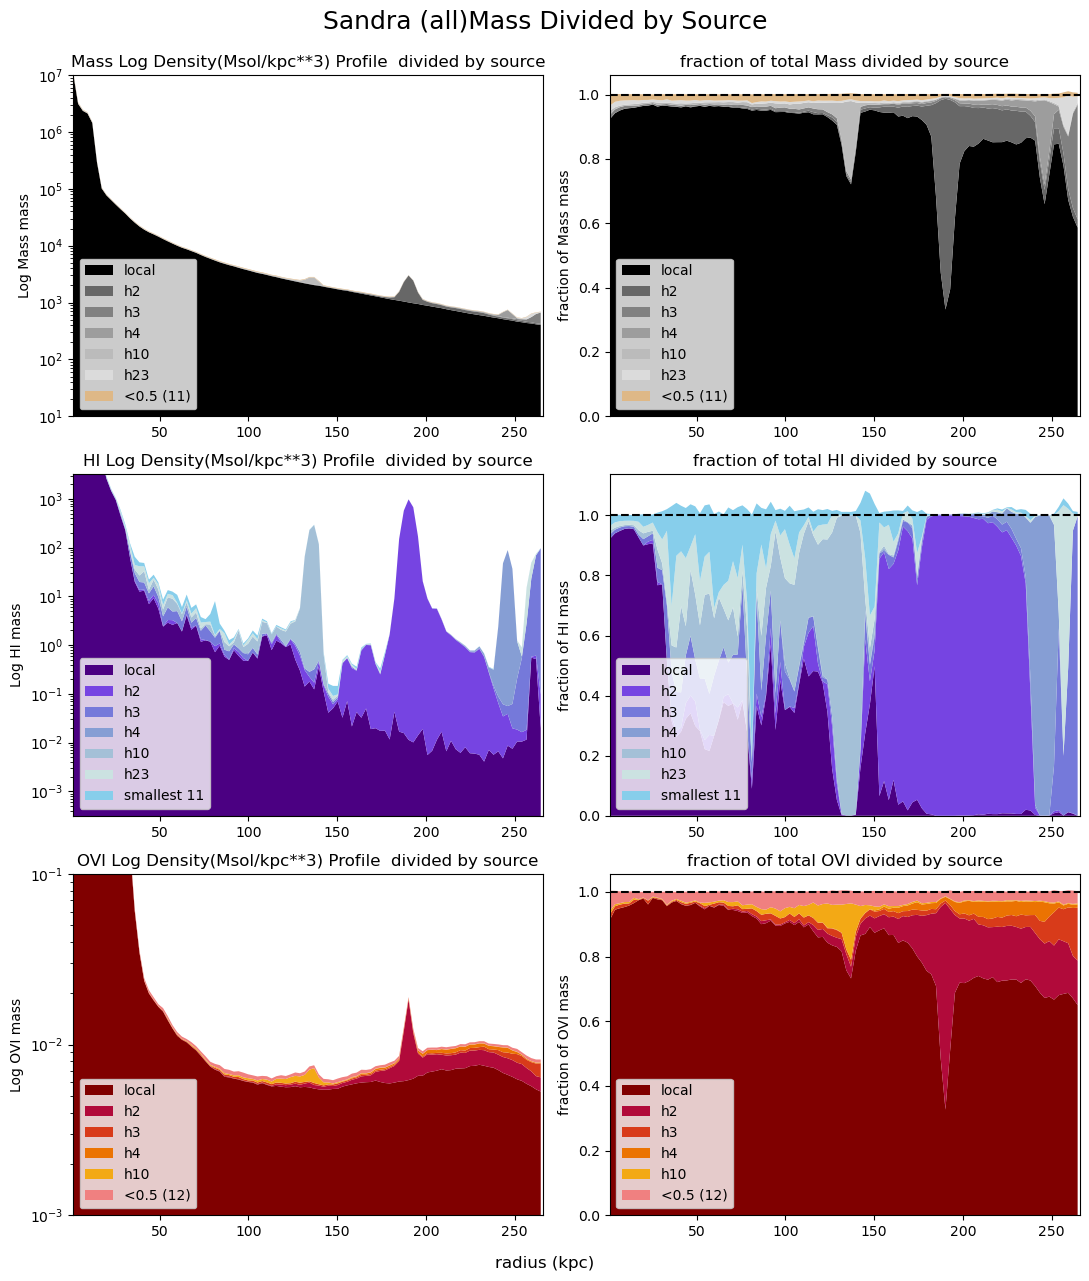

In [28]:

readin = True
for filename in filenames:
    edge = int(simulations.at[filename, 'Rvir'])
    data_name = data_filepath + filename +"Halo Charachteristics.csv"
    if readin:      
        HaloChars = pd.read_csv(data_name, index_col = 0)
        HaloChars = base.FormatDF(HaloChars)
    else:
        s, h1, h = base.load_in_sim(filename, return_h = True)
        ions.calculate_gas_mass(s)
        subsims = tracking.find_halo_particles(h1, filename)##returns a dictionary of subsims for all halos in the simulations, 
        HaloChars = getHaloChars(h1, subsims,edge)
        HaloChars.to_csv(data_name)
    try:
        sHaloChars = HaloChars.drop(['halos', 'total'])
    except KeyError:
        sHaloChars = HaloChars
        pass
    make_all_stacks(sHaloChars, filename,edge )

In [89]:
OVI_cmap = mpl.colormaps['cmr.ember'](np.linspace(0.3,0.8, len(sims)))
HI_cmap = mpl.colormaps['cmr.amethyst'](np.linspace(0.05,0.65, len(sims)))

In [35]:
def readInData(filename):
    path = data_filepath + filename +"Halo Charachteristics.csv"
    HaloChars = pd.read_csv(path, index_col = 0)
    HaloChars = base.FormatDF(HaloChars)
    return HaloChars

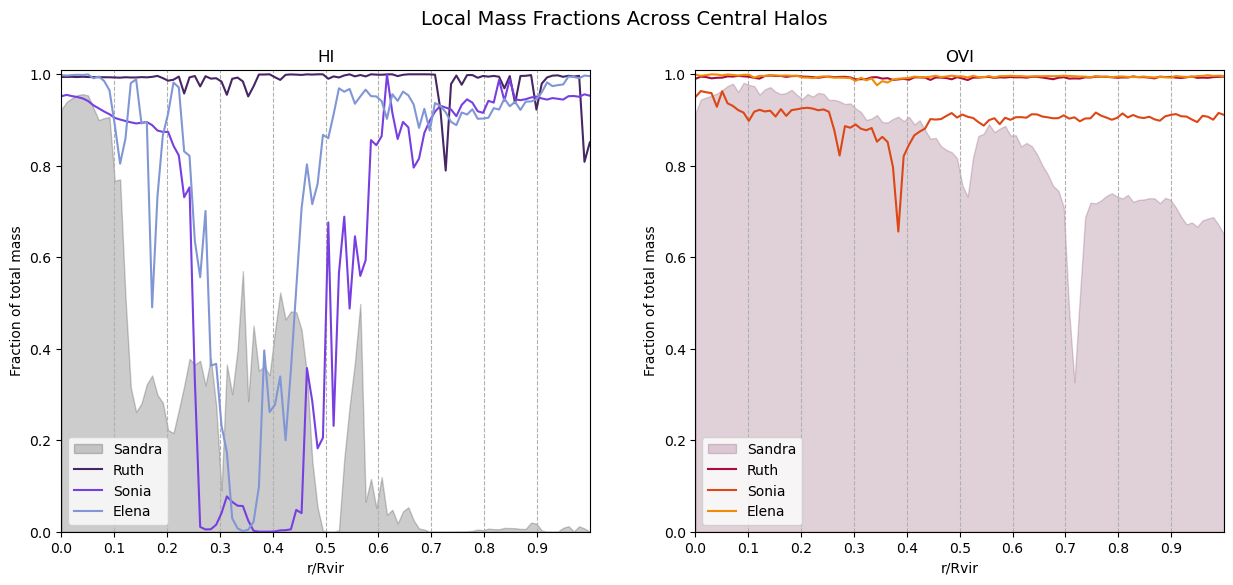

In [90]:
fig, axs = plt.subplots(1,2,figsize=(15,6))
ions = ['HI', 'OVI']        
sims = ['Sandra', 'Ruth','Sonia', 'Elena']
all_colors = [HI_cmap, OVI_cmap]

radii =np.linspace(0,1,100)
for col, ion in enumerate(ions):
    ax = axs[col]
    pltColors = all_colors[col]
    value = ion+"_Ratios"
    for index, filename in enumerate(sims):
        HaloChars= readInData(filename)

        fractions = HaloChars[value]['local']

        if index == 0:
            ax.fill_between(radii, fractions,  label=(filename),ls = '-', color=pltColors[index], alpha = 0.2)
        else:
            ax.plot(radii, fractions, label=(filename), ls = '-', color=pltColors[index])

        
    ax.set_title(ion)

    ax.set_xticks(np.arange(0, 1, 0.1))
    ax.set_xlabel('r/Rvir')
    ax.set_ylabel('Fraction of total mass')
    ax.legend()     
    ax.xaxis.grid(True, which='major', linestyle = "--")
    ax.set_ylim(0,1.01)
    ax.set_xlim(0,1)
    

fig.suptitle('Local Mass Fractions Across Central Halos', fontsize = 14)

    

# plotname = "HI vs OVI Covering Fractions for " + filename +".png"
# fig.savefig(folder_path + '/CF_plots/'+ plotname)
plotname = "HI vs OVI Fractions for all sims.png"
fig.savefig(plotname)


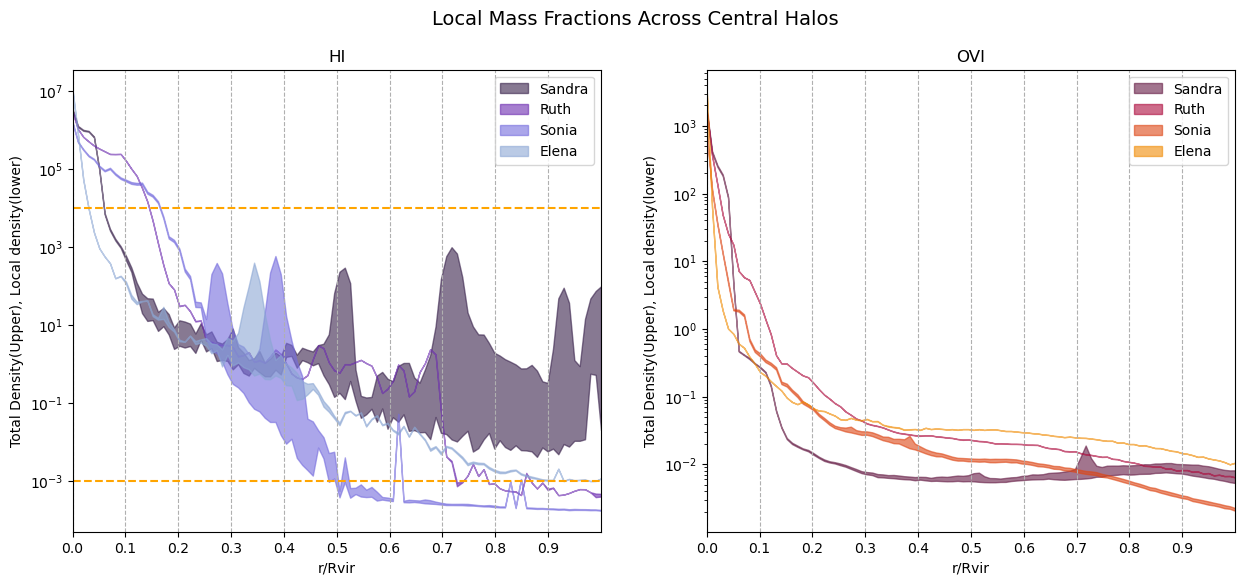

In [87]:
fig, axs = plt.subplots(1,2,figsize=(15,6))
ions = ['HI', 'OVI']        
sims = ['Sandra', 'Ruth','Sonia', 'Elena']
OVI_cmap = mpl.colormaps['cmr.ember'](np.linspace(0.3,0.8, len(sims)))
HI_cmap = mpl.colormaps['cmr.amethyst'](np.linspace(0.2,0.7, len(sims)))
all_colors = [HI_cmap, OVI_cmap]


radii =np.linspace(0,1,100)
for col, ion in enumerate(ions):
    ax = axs[col]
    pltColors = all_colors[col]
    value = ion+"_Density"
    for index, filename in enumerate(sims):
        HaloChars= readInData(filename)

        total = HaloChars[value]['total']
        local = HaloChars[value]['local']


        plot = ax.fill_between(radii, total, local,  label=(filename),ls = '-', color=pltColors[index], alpha = 0.6)


    ax.set_yscale('log')
    ax.set_title(ion)
    ax.set_xticks(np.arange(0, 1, 0.1))
    ax.set_xlabel('r/Rvir')
    ax.set_ylabel('Total Density(Upper), Local density(lower)')
    ax.legend()     
    ax.xaxis.grid(True, which='major', linestyle = "--")
    ax.set_xlim(0,1)
    

fig.suptitle('Local Mass Fractions Across Central Halos', fontsize = 14)
axs[0].axhline(10**-3,color = 'orange', linestyle = '--')
axs[0].axhline(10**4,color = 'orange', linestyle = '--')    

plotname = "HI vs OVI Densities for all sims.png"
fig.savefig(plotname)


In [ ]:
sHaloChars

In [ ]:
subsims = tracking.find_halo_particles(h1, simulations, filename, groupSmalls = True)##returns a dictionary of subsims for all halos in the simulations, 